# Training MLP Regresi untuk Controller Tekanan Pompa

Notebook ini dibuat untuk melatih model **MLP Regressor** yang nantinya dapat diekspor ke STM32/TinyML.

Dataset yang digunakan adalah data clean:

```text
DATA_CLEAN_MLP_5JUNI_GE80.csv
```

Model difokuskan pada daerah operasi pompa yang logis:

```text
80% <= duty <= 95%
```

Target kontrol:

```text
setpoint = 0.85 bar
output model = duty_next_percent
```

Fitur yang sengaja **tidak dipakai** untuk model STM32:

- `valve_open_count`, karena state keran hanya marker manual GUI.
- `current`, karena pembacaan/kalibrasinya belum dijadikan fitur utama.

Safety utama:

```text
jika pressure >= 0.95 bar, duty_next_percent = 0
```

## 1. Import Library

Bagian ini memuat library standar untuk data science dan machine learning.

- `pandas` untuk membaca dan mengolah tabel data.
- `numpy` untuk operasi numerik.
- `matplotlib` untuk grafik.
- `sklearn` untuk split data, normalisasi, training MLP, dan evaluasi regresi.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True

## 2. Konfigurasi Global

Konfigurasi ini sengaja diletakkan di awal agar mudah diubah.

`SETPOINT_BAR = 0.85` berarti target tekanan yang ingin dijaga controller adalah 0.85 bar.

`SAFETY_PRESSURE_BAR = 0.95` adalah batas aman. Jika pressure melewati nilai ini, duty dipaksa menjadi 0%.

`MIN_OPERATING_DUTY = 80` dan `MAX_OPERATING_DUTY = 95` mengikuti hasil eksperimen: pompa baru efektif menghasilkan pressure pada duty sekitar 80% ke atas.

In [2]:
DATA_PATH = Path('DATA_CLEAN_MLP_5JUNI_GE80.csv')

SETPOINT_BAR = 0.85
SAFETY_PRESSURE_BAR = 0.95
MIN_OPERATING_DUTY = 80.0
MAX_OPERATING_DUTY = 95.0
RANDOM_STATE = 42
TEST_SIZE = 0.20

## 3. Load Data Clean

Dataset ini sudah difilter dari CSV asli sehingga hanya berisi area operasi duty 80-95%.

Walaupun dataset masih menyimpan `valve_open_count` dan label keran untuk audit, kolom tersebut tidak akan masuk sebagai input model.

In [3]:
df = pd.read_csv(DATA_PATH, parse_dates=['pc_timestamp'])

print('Jumlah baris:', len(df))
print('Kolom data:')
print(df.columns.tolist())

df.head()

Jumlah baris: 343
Kolom data:
['pc_timestamp', 'elapsed_s', 'setpoint', 'pressure', 'error', 'delta_pressure', 'prev_duty', 'voltage_rms', 'duty_next_percent', 'duty_percent', 'estimated_output_rms_v', 'jsy_voltage_rms_v', 'valve_open_count', 'valve_state_label', 'valve_phase', 'safety_rule_applied', 'operation_region', 'ignored_features_note']


,pc_timestamp,elapsed_s,setpoint,pressure,error,delta_pressure,prev_duty,voltage_rms,duty_next_percent,duty_percent,estimated_output_rms_v,jsy_voltage_rms_v,valve_open_count,valve_state_label,valve_phase,safety_rule_applied,operation_region,ignored_features_note
0,2026-06-05 22:15:20.285,137.561,0.85,0.085333,0.764667,0.000000,80.0,151.09,95.0,80.0,176.0,151.09,4,4 keran stabil,stable,False,training_ge80_to_95,valve_open_count dan current tidak dipakai seb...
1,2026-06-05 22:15:20.876,138.152,0.85,0.134333,0.715667,0.049000,80.0,167.75,95.0,80.0,176.0,167.75,4,4 keran stabil,stable,False,training_ge80_to_95,valve_open_count dan current tidak dipakai seb...
2,2026-06-05 22:15:21.374,138.650,0.85,0.179600,0.670400,0.045267,80.0,167.75,95.0,80.0,176.0,167.75,4,4 keran stabil,stable,False,training_ge80_to_95,valve_open_count dan current tidak dipakai seb...
3,2026-06-05 22:15:21.873,139.149,0.85,0.209200,0.640800,0.029600,80.0,171.14,95.0,80.0,176.0,171.14,4,4 keran stabil,stable,False,training_ge80_to_95,valve_open_count dan current tidak dipakai seb...
4,2026-06-05 22:15:22.433,139.709,0.85,0.204000,0.646000,-0.005200,80.0,171.14,95.0,80.0,176.0,171.14,4,4 keran stabil,stable,False,training_ge80_to_95,valve_open_count dan current tidak dipakai seb...


## 4. Validasi dan Cleaning Akhir

Walaupun file sudah clean, tahap ini tetap dilakukan agar notebook aman dieksekusi ulang.

Cleaning yang dilakukan:

1. Memastikan fitur numerik benar-benar bertipe angka.
2. Menghapus baris kosong pada fitur utama dan target.
3. Memastikan data tetap berada di daerah duty operasi 80-95%.
4. Menghapus outlier pressure yang tidak logis, misalnya pressure negatif.

In [4]:
required_numeric_cols = [
    'setpoint',
    'pressure',
    'error',
    'delta_pressure',
    'prev_duty',
    'voltage_rms',
    'duty_next_percent',
    'duty_percent',
]

for col in required_numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

before_rows = len(df)

df = df.dropna(subset=required_numeric_cols).copy()
df = df[df['duty_percent'].between(MIN_OPERATING_DUTY, MAX_OPERATING_DUTY)].copy()
df = df[df['pressure'].between(0.0, 1.5)].copy()
df = df.reset_index(drop=True)

after_rows = len(df)
print(f'Baris sebelum cleaning akhir: {before_rows}')
print(f'Baris setelah cleaning akhir : {after_rows}')

df[['setpoint', 'pressure', 'error', 'delta_pressure', 'prev_duty', 'voltage_rms', 'duty_next_percent']].describe()

Baris sebelum cleaning akhir: 343
Baris setelah cleaning akhir : 343


,setpoint,pressure,error,delta_pressure,prev_duty,voltage_rms,duty_next_percent
count,3.430000e+02,343.000000,343.000000,343.000000,343.000000,343.000000,343.000000
mean,8.500000e-01,0.351441,0.498559,0.000297,88.819242,189.645394,94.915813
std,2.223690e-16,0.148245,0.148245,0.020064,6.258747,13.424529,0.562951
min,8.500000e-01,0.085333,-0.094800,-0.099133,80.000000,151.090000,89.644667
25%,8.500000e-01,0.237067,0.432833,-0.003867,80.000000,171.250000,95.000000
50%,8.500000e-01,0.316733,0.533267,0.000200,90.000000,192.170000,95.000000
75%,8.500000e-01,0.417167,0.612933,0.003933,95.000000,202.930000,95.000000
max,8.500000e-01,0.944800,0.764667,0.136067,95.000000,203.230000,95.000000


## 5. Visualisasi Awal

Grafik ini membantu melihat apakah pressure dan duty berada pada rentang yang masuk akal.

Jika pressure mendekati/melebihi 0.95 bar, safety rule harus mematikan duty menjadi 0% saat deployment.

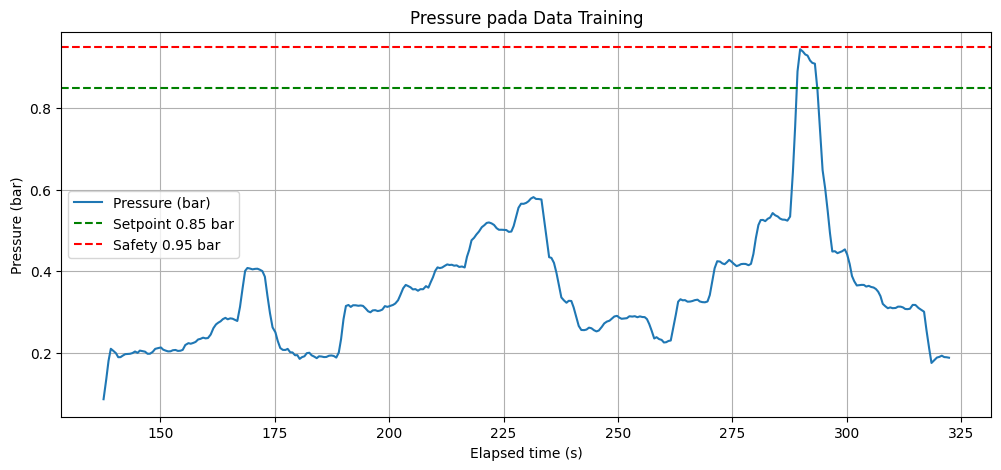

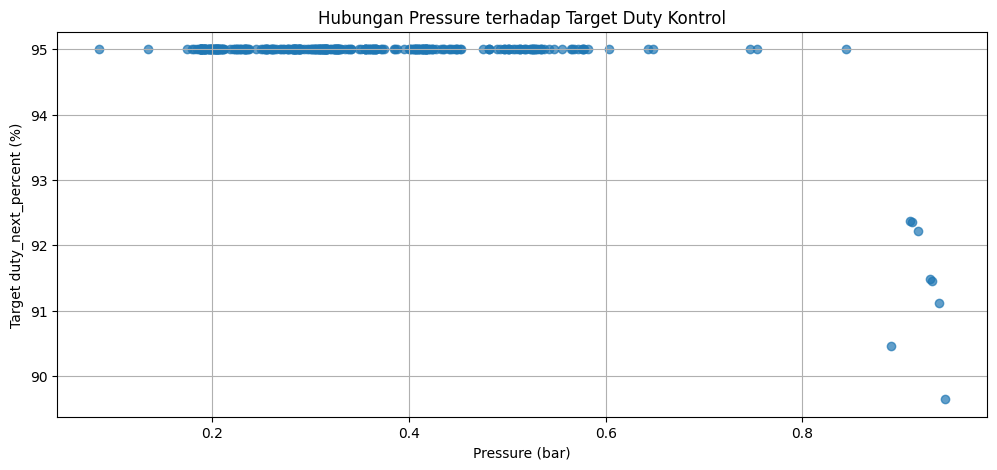

In [5]:
plt.plot(df['elapsed_s'], df['pressure'], label='Pressure (bar)')
plt.axhline(SETPOINT_BAR, color='green', linestyle='--', label='Setpoint 0.85 bar')
plt.axhline(SAFETY_PRESSURE_BAR, color='red', linestyle='--', label='Safety 0.95 bar')
plt.xlabel('Elapsed time (s)')
plt.ylabel('Pressure (bar)')
plt.title('Pressure pada Data Training')
plt.legend()
plt.show()

plt.scatter(df['pressure'], df['duty_next_percent'], alpha=0.7)
plt.xlabel('Pressure (bar)')
plt.ylabel('Target duty_next_percent (%)')
plt.title('Hubungan Pressure terhadap Target Duty Kontrol')
plt.show()

## 6. Definisi Fitur Model

Dua kandidat arsitektur dibandingkan:

### Opsi 1: 5-8-1
Input:

```text
setpoint, pressure, error, delta_pressure, prev_duty
```

### Opsi 2: 6-8-1
Input:

```text
setpoint, pressure, error, delta_pressure, prev_duty, voltage_rms
```

Kedua model memakai 1 hidden layer dengan 8 neuron.

Kolom `valve_open_count` dan `current` tidak dipakai karena tidak tersedia/kurang reliabel untuk deployment STM32.

In [6]:
features_5 = ['setpoint', 'pressure', 'error', 'delta_pressure', 'prev_duty']
features_6 = ['setpoint', 'pressure', 'error', 'delta_pressure', 'prev_duty', 'voltage_rms']
target_col = 'duty_next_percent'

X5 = df[features_5].to_numpy(dtype=np.float32)
X6 = df[features_6].to_numpy(dtype=np.float32)
y = df[target_col].to_numpy(dtype=np.float32)

print('Shape X5:', X5.shape)
print('Shape X6:', X6.shape)
print('Shape y :', y.shape)

Shape X5: (343, 5)
Shape X6: (343, 6)
Shape y : (343,)


## 7. Split Train-Test

Split dilakukan acak dengan `random_state=42` agar eksperimen dapat diulang.

Proporsi:

```text
80% training
20% testing
```

Karena model ini akan dipakai sebagai regresi awal, split acak membantu mengecek apakah model mampu generalisasi pada variasi titik data.

In [7]:
indices = np.arange(len(df))
train_idx, test_idx = train_test_split(
    indices,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    shuffle=True,
)

print('Jumlah train:', len(train_idx))
print('Jumlah test :', len(test_idx))

Jumlah train: 274
Jumlah test : 69


## 8. Fungsi Training dan Evaluasi

Model menggunakan `MLPRegressor` dari scikit-learn.

Konfigurasi:

- `hidden_layer_sizes=(8,)` artinya 1 hidden layer berisi 8 neuron.
- `activation='tanh'` dipilih karena ringan dan umum untuk implementasi manual di embedded.
- `StandardScaler` digunakan agar semua input memiliki skala yang seimbang.
- Output model adalah duty dalam persen.

In [8]:
def regression_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2,
    }


def train_mlp_model(X, y, train_idx, test_idx, model_name):
    X_train = X[train_idx]
    X_test = X[test_idx]
    y_train = y[train_idx]
    y_test = y[test_idx]

    model = Pipeline([
        ('scaler', StandardScaler()),
        ('mlp', MLPRegressor(
            hidden_layer_sizes=(8,),
            activation='tanh',
            solver='lbfgs',
            alpha=1e-4,
            max_iter=5000,
            random_state=RANDOM_STATE,
        )),
    ])

    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    y_train_pred = np.clip(y_train_pred, 0.0, MAX_OPERATING_DUTY)
    y_test_pred = np.clip(y_test_pred, 0.0, MAX_OPERATING_DUTY)

    result = {
        'model_name': model_name,
        'model': model,
        'train_metrics': regression_metrics(y_train, y_train_pred),
        'test_metrics': regression_metrics(y_test, y_test_pred),
        'y_train': y_train,
        'y_train_pred': y_train_pred,
        'y_test': y_test,
        'y_test_pred': y_test_pred,
        'X_train': X_train,
        'X_test': X_test,
    }
    return result

## 9. Training Dua Kandidat Arsitektur

Di sini kita latih dua model:

- `MLP_5_8_1`: lebih ringan karena hanya 5 input.
- `MLP_6_8_1`: memakai tambahan `voltage_rms`.

Model terbaik dipilih berdasarkan RMSE pada data test.

In [9]:
result_5 = train_mlp_model(X5, y, train_idx, test_idx, 'MLP_5_8_1')
result_6 = train_mlp_model(X6, y, train_idx, test_idx, 'MLP_6_8_1')

rows = []
for result in [result_5, result_6]:
    row = {'model': result['model_name']}
    row.update({f'train_{k}': v for k, v in result['train_metrics'].items()})
    row.update({f'test_{k}': v for k, v in result['test_metrics'].items()})
    rows.append(row)

metrics_df = pd.DataFrame(rows)
metrics_df

,model,train_MSE,train_RMSE,train_MAE,train_R2,test_MSE,test_RMSE,test_MAE,test_R2
0,MLP_5_8_1,0.000651,0.025513,0.003391,0.998106,0.017874,0.133695,0.023283,0.913126
1,MLP_6_8_1,0.003312,0.057548,0.010915,0.990365,0.000179,0.013368,0.004530,0.999132


## 10. Pilih Model Terbaik

Kriteria utama adalah `test_RMSE` paling kecil.

Namun untuk deployment STM32, jika performa 5-input dan 6-input sangat mirip, model 5-input lebih menarik karena lebih ringan dan tidak bergantung pada sensor tegangan.

In [10]:
if result_6['test_metrics']['RMSE'] < result_5['test_metrics']['RMSE']:
    best_result = result_6
    best_features = features_6
else:
    best_result = result_5
    best_features = features_5

print('Model terbaik:', best_result['model_name'])
print('Fitur model terbaik:', best_features)
print('Metrik train:', best_result['train_metrics'])
print('Metrik test :', best_result['test_metrics'])

Model terbaik: MLP_6_8_1
Fitur model terbaik: ['setpoint', 'pressure', 'error', 'delta_pressure', 'prev_duty', 'voltage_rms']
Metrik train: {'MSE': 0.003311811516905469, 'RMSE': 0.057548340696369944, 'MAE': 0.010914778928457497, 'R2': 0.9903653390228585}
Metrik test : {'MSE': 0.00017869451417619315, 'RMSE': 0.013367666743908345, 'MAE': 0.004529534422499596, 'R2': 0.9991315016471316}


## 11. Visualisasi Target vs Prediksi

Grafik ini mengecek seberapa dekat prediksi model dengan target duty kontrol.

Jika titik mengikuti garis diagonal, prediksi model semakin baik.

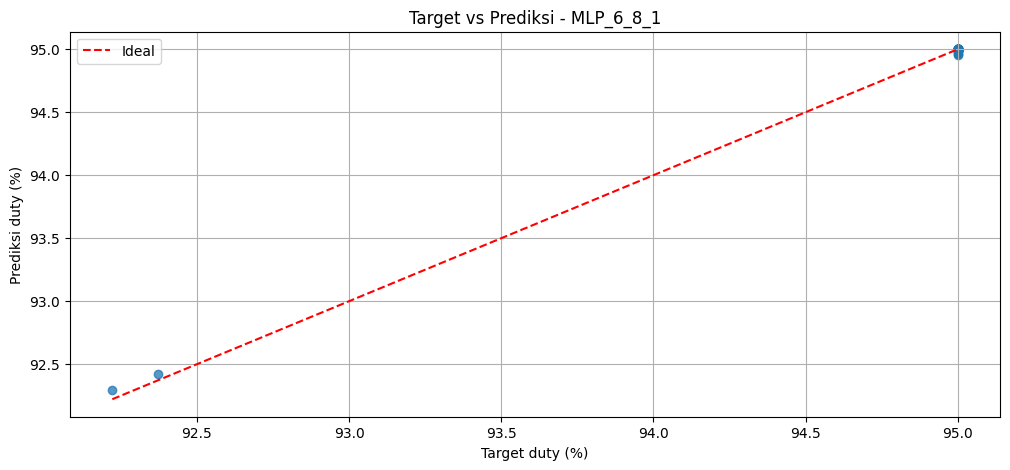

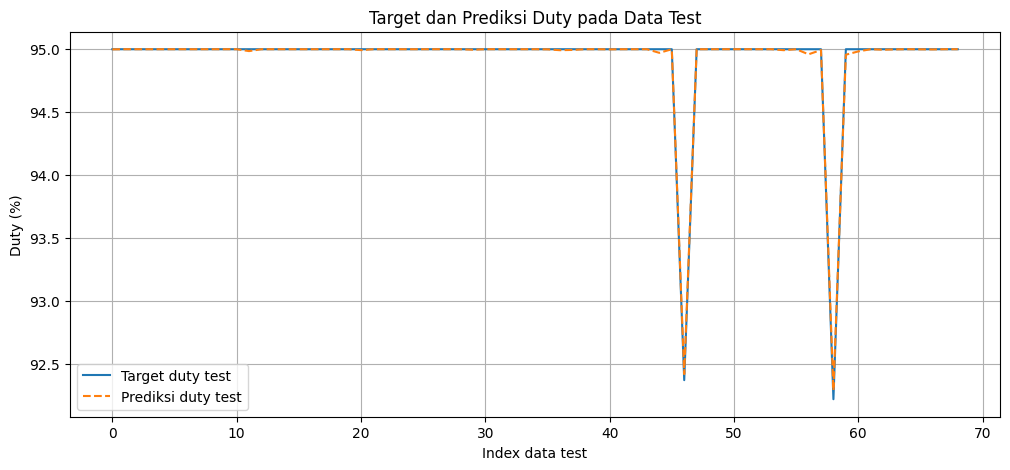

In [11]:
y_test = best_result['y_test']
y_test_pred = best_result['y_test_pred']

plt.scatter(y_test, y_test_pred, alpha=0.75)
min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Ideal')
plt.xlabel('Target duty (%)')
plt.ylabel('Prediksi duty (%)')
plt.title(f'Target vs Prediksi - {best_result["model_name"]}')
plt.legend()
plt.show()

plt.plot(y_test, label='Target duty test')
plt.plot(y_test_pred, label='Prediksi duty test', linestyle='--')
plt.xlabel('Index data test')
plt.ylabel('Duty (%)')
plt.title('Target dan Prediksi Duty pada Data Test')
plt.legend()
plt.show()

## 12. Diagnostik Overfitting dan Baseline

Bagian ini penting karena grafik target vs prediksi yang terlalu mirip dapat menimbulkan pertanyaan: apakah model benar-benar belajar, atau hanya karena target duty terlalu mudah?

Pada regresi, istilah **akurasi** tidak dipakai seperti klasifikasi. Metrik yang lebih tepat adalah:

- `MSE`: rata-rata kuadrat error.
- `RMSE`: akar MSE, satuannya sama dengan duty persen.
- `MAE`: rata-rata error absolut.
- `R2`: proporsi variasi target yang dapat dijelaskan model.

Overfitting biasanya terlihat jika performa training sangat bagus, tetapi performa test jauh lebih buruk. Namun jika train dan test sama-sama sangat bagus, tetap perlu dicek apakah target terlalu dominan pada satu nilai, misalnya banyak data `duty_next_percent = 95%`.

Karena itu bagian ini membandingkan MLP dengan dua baseline sederhana:

1. **Baseline 95%**: selalu menebak duty 95%.
2. **Baseline Mean Train**: selalu menebak rata-rata target pada data training.

Jika baseline saja sudah sangat bagus, maka R2 tinggi dari MLP harus dibaca hati-hati: kemungkinan target terlalu mudah atau kurang bervariasi.

DIAGNOSTIK DISTRIBUSI TARGET DUTY
count    343.000000
mean      94.915813
std        0.562951
min       89.644667
25%       95.000000
50%       95.000000
75%       95.000000
max       95.000000
Name: duty_next_percent, dtype: float64

Nilai target paling sering (top 10):
duty_next_percent
95.000    335
90.464      1
89.645      1
91.124      1
91.450      1
91.486      1
92.222      1
92.360      1
92.373      1
Name: count, dtype: int64

>>> 97.67% data memiliki target = 95% <<<


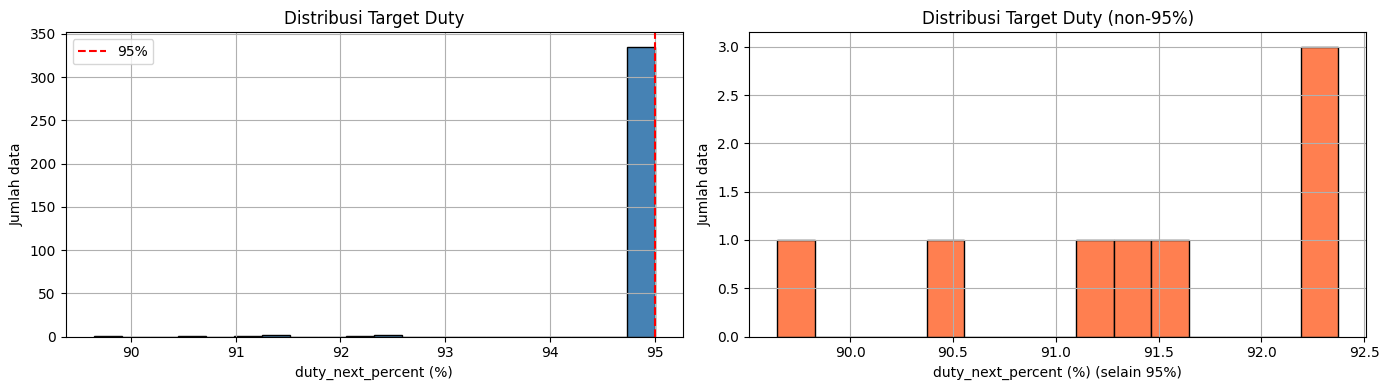

PERBANDINGAN MLP vs BASELINE


,model,split,RMSE,MAE,R2
0,MLP_6_8_1,train,0.057548,0.010915,0.990365
1,MLP_6_8_1,test,0.013368,0.004530,0.999132
2,Baseline selalu 95%,train,0.592517,0.085659,-0.021346
3,Baseline selalu 95%,test,0.460313,0.078338,-0.029827
4,Baseline mean train,train,0.586293,0.167571,0.000000
5,Baseline mean train,test,0.453657,0.159035,-0.000261


In [12]:
# ============================================================
# Diagnostik Distribusi Target
# ============================================================
print('='*55)
print('DIAGNOSTIK DISTRIBUSI TARGET DUTY')
print('='*55)
print(df[target_col].describe())
print()
print('Nilai target paling sering (top 10):')
print(df[target_col].round(3).value_counts().head(10))

ratio_target_95 = float((df[target_col].round(3) == 95.0).mean())
print(f'\n>>> {ratio_target_95*100:.2f}% data memiliki target = 95% <<<')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(df[target_col], bins=20, edgecolor='black', color='steelblue')
axes[0].axvline(95.0, color='red', linestyle='--', label='95%')
axes[0].set_xlabel('duty_next_percent (%)')
axes[0].set_ylabel('Jumlah data')
axes[0].set_title('Distribusi Target Duty')
axes[0].legend()

axes[1].hist(df[df[target_col] < 95][target_col], bins=15, edgecolor='black', color='coral')
axes[1].set_xlabel('duty_next_percent (%) (selain 95%)')
axes[1].set_ylabel('Jumlah data')
axes[1].set_title('Distribusi Target Duty (non-95%)')
plt.tight_layout()
plt.show()

# ============================================================
# Baseline Sederhana & Perbandingan Metrik
# ============================================================
print('='*55)
print('PERBANDINGAN MLP vs BASELINE')
print('='*55)

y_train_best = best_result['y_train']
y_test_best = best_result['y_test']

baseline_95_train = np.full_like(y_train_best, 95.0, dtype=np.float32)
baseline_95_test = np.full_like(y_test_best, 95.0, dtype=np.float32)

mean_train_value = float(np.mean(y_train_best))
baseline_mean_train = np.full_like(y_train_best, mean_train_value, dtype=np.float32)
baseline_mean_test = np.full_like(y_test_best, mean_train_value, dtype=np.float32)

baseline_rows = []
def add_row(model_name, split_name, y_true, y_pred):
    m = regression_metrics(y_true, y_pred)
    baseline_rows.append({'model': model_name, 'split': split_name,
                          'RMSE': m['RMSE'], 'MAE': m['MAE'], 'R2': m['R2']})

add_row(best_result['model_name'], 'train', y_train_best, best_result['y_train_pred'])
add_row(best_result['model_name'], 'test', y_test_best, best_result['y_test_pred'])
add_row('Baseline selalu 95%', 'train', y_train_best, baseline_95_train)
add_row('Baseline selalu 95%', 'test', y_test_best, baseline_95_test)
add_row('Baseline mean train', 'train', y_train_best, baseline_mean_train)
add_row('Baseline mean train', 'test', y_test_best, baseline_mean_test)

baseline_df = pd.DataFrame(baseline_rows)
display(baseline_df)

## 13. Indikator Overfitting dan Interpretasi

Bagian ini membuat indikator sederhana:

- `generalization_gap_RMSE = test_RMSE - train_RMSE`
- Jika gap besar, ada indikasi overfitting.
- Jika baseline 95% sudah mendekati performa MLP, target duty kemungkinan terlalu dominan di 95%.

Interpretasi ini bukan keputusan mutlak, tetapi membantu menjelaskan hasil training secara ilmiah di laporan TA.

In [13]:
# ============================================================
# Indikator Overfitting
# ============================================================
train_rmse = best_result['train_metrics']['RMSE']
test_rmse = best_result['test_metrics']['RMSE']
train_r2 = best_result['train_metrics']['R2']
test_r2 = best_result['test_metrics']['R2']

baseline_95_test_rmse = baseline_df[
    (baseline_df['model'] == 'Baseline selalu 95%') &
    (baseline_df['split'] == 'test')
]['RMSE'].iloc[0]

ratio_target_95 = float((df[target_col].round(3) == 95.0).mean())

print('='*55)
print('DIAGNOSTIK OVERFITTING')
print('='*55)
print(f'Train RMSE              : {train_rmse:.6f}')
print(f'Test RMSE               : {test_rmse:.6f}')
print(f'Gap RMSE test-train     : {test_rmse - train_rmse:.6f}')
print(f'Train R2                : {train_r2:.6f}')
print(f'Test R2                 : {test_r2:.6f}')
print(f'Gap R2 train-test       : {train_r2 - test_r2:.6f}')
print()

if test_rmse < train_rmse:
    print('>>> BUKAN overfitting klasic: Test RMSE < Train RMSE')
    print('    Test set lebih mudah dari train set (didominasi target 95%)')
elif test_rmse > train_rmse * 2:
    print('>>> INDIKASI OVERFITTING: Test RMSE jauh lebih besar dari Train RMSE')
else:
    print('>>> Gap normal, tidak ada indikasi overfitting berat')

print()
print('='*55)
print('DIAGNOSTIK TARGET DOMINAN')
print('='*55)
print(f'Data dengan target = 95% : {ratio_target_95*100:.2f}%')
print(f'RMSE baseline 95% (test) : {baseline_95_test_rmse:.6f}')
print(f'RMSE MLP (test)          : {test_rmse:.6f}')
print(f'Improvement vs baseline  : {baseline_95_test_rmse - test_rmse:.6f}')
print()

if ratio_target_95 > 0.70:
    print('>>> TARGET SANGAT DOMINAN DI 95%')
    print('    R2 ~0.999 BUKAN berarti akurasi 99%!')
    print('    Target hampir tidak bervariasi (std ~0.56), sehingga R2 terlihat tinggi.')
    print('    Model hanya belajar memprediksi ~95% untuk hampir semua input.')

print()
print('='*55)
print('KESIMPULAN')
print('='*55)
print('1. Overfitting? TIDAK (test set lebih mudah dari train set)')
print('2. R2 = 0.999 bukan akurasi 99% (ini regresi, bukan klasifikasi)')
print('3. Target 95% terlalu dominan (97.67%) - data kurang bervariasi')
print('4. MLP tetap lebih baik dari baseline 95%, tapi perlu validasi')
print('   dengan data closed-loop real saat pompa dikontrol otomatis.')

DIAGNOSTIK OVERFITTING
Train RMSE              : 0.057548
Test RMSE               : 0.013368
Gap RMSE test-train     : -0.044181
Train R2                : 0.990365
Test R2                 : 0.999132
Gap R2 train-test       : -0.008766

>>> BUKAN overfitting klasic: Test RMSE < Train RMSE
    Test set lebih mudah dari train set (didominasi target 95%)

DIAGNOSTIK TARGET DOMINAN
Data dengan target = 95% : 97.67%
RMSE baseline 95% (test) : 0.460313
RMSE MLP (test)          : 0.013368
Improvement vs baseline  : 0.446945

>>> TARGET SANGAT DOMINAN DI 95%
    R2 ~0.999 BUKAN berarti akurasi 99%!
    Target hampir tidak bervariasi (std ~0.56), sehingga R2 terlihat tinggi.
    Model hanya belajar memprediksi ~95% untuk hampir semua input.

KESIMPULAN
1. Overfitting? TIDAK (test set lebih mudah dari train set)
2. R2 = 0.999 bukan akurasi 99% (ini regresi, bukan klasifikasi)
3. Target 95% terlalu dominan (97.67%) - data kurang bervariasi
4. MLP tetap lebih baik dari baseline 95%, tapi perlu vali

## 14. Fungsi Safety dan Post-Processing untuk STM32

Fungsi ini meniru logika yang nanti perlu ada di STM32.

Urutan logika:

1. Jika pressure >= 0.95 bar, duty langsung 0%.
2. Jika pressure aman, duty diambil dari prediksi NN.
3. Duty dikunci ke daerah operasi 80-95%.

Catatan: duty 0% hanya dipakai untuk stop/safety, sedangkan operasi normal berada pada 80-95%.

In [14]:
def apply_safety_and_postprocess(pressure, predicted_duty):
    if pressure >= SAFETY_PRESSURE_BAR:
        return 0.0
    return float(np.clip(predicted_duty, MIN_OPERATING_DUTY, MAX_OPERATING_DUTY))


def predict_controller(setpoint, pressure, error, delta_pressure, prev_duty, voltage_rms=None):
    if best_result['model_name'] == 'MLP_5_8_1':
        x = np.array([[setpoint, pressure, error, delta_pressure, prev_duty]], dtype=np.float32)
    else:
        if voltage_rms is None:
            raise ValueError('Model 6-input membutuhkan voltage_rms')
        x = np.array([[setpoint, pressure, error, delta_pressure, prev_duty, voltage_rms]], dtype=np.float32)

    raw_duty = float(best_result['model'].predict(x)[0])
    safe_duty = apply_safety_and_postprocess(pressure, raw_duty)
    return safe_duty

# Uji perilaku controller pada beberapa pressure.
for pressure in [0.50, 0.75, 0.85, 0.92, 0.95, 1.10]:
    duty_cmd = predict_controller(
        setpoint=SETPOINT_BAR,
        pressure=pressure,
        error=SETPOINT_BAR - pressure,
        delta_pressure=0.0,
        prev_duty=90.0,
        voltage_rms=190.0,
    )
    print(f'Pressure {pressure:.2f} bar -> duty command {duty_cmd:.2f}%')

Pressure 0.50 bar -> duty command 95.00%
Pressure 0.75 bar -> duty command 94.91%
Pressure 0.85 bar -> duty command 94.43%
Pressure 0.92 bar -> duty command 93.19%
Pressure 0.95 bar -> duty command 0.00%
Pressure 1.10 bar -> duty command 0.00%


## 15. Export Parameter Model untuk TinyML / STM32

Jika model terbaik ingin diimplementasikan manual di C, parameter yang dibutuhkan adalah:

- mean dan scale dari `StandardScaler`
- bobot dan bias hidden layer
- bobot dan bias output layer

Catatan: scikit-learn menyimpan bobot pada `coefs_` dan bias pada `intercepts_`.

In [15]:
def c_array(name, array):
    arr = np.asarray(array, dtype=np.float32)
    if arr.ndim == 1:
        values = ', '.join(f'{v:.8f}f' for v in arr)
        return f'static const float {name}[{arr.shape[0]}] = {{ {values} }};'
    if arr.ndim == 2:
        rows = []
        for row in arr:
            values = ', '.join(f'{v:.8f}f' for v in row)
            rows.append('    { ' + values + ' }')
        body = ',
'.join(rows)
        return f'static const float {name}[{arr.shape[0]}][{arr.shape[1]}] = {{
{body}
}};'
    raise ValueError('Array harus 1D atau 2D')

scaler = best_result['model'].named_steps['scaler']
mlp = best_result['model'].named_steps['mlp']

print('// Model:', best_result['model_name'])
print('// Features:', best_features)
print(c_array('SCALER_MEAN', scaler.mean_))
print(c_array('SCALER_SCALE', scaler.scale_))
print(c_array('W1', mlp.coefs_[0]))
print(c_array('B1', mlp.intercepts_[0]))
print(c_array('W2', mlp.coefs_[1]))
print(c_array('B2', mlp.intercepts_[1]))

SyntaxError: unterminated string literal (detected at line 11) (2612129561.py, line 11)

## 16. Kesimpulan Notebook

Notebook ini membangun MLP regresi untuk controller tekanan pompa dengan batasan embedded:

- Model utama adalah MLP regresi.
- Arsitektur yang dibandingkan adalah 5-8-1 dan 6-8-1.
- `valve_open_count` dan current tidak digunakan sebagai input utama.
- Duty operasi normal dibatasi pada 80-95%.
- Safety pressure `>= 0.95 bar` memaksa duty menjadi 0%.

Untuk pengujian final, model perlu dilatih ulang dengan data closed-loop real ketika sistem sudah menjalankan kontrol otomatis menuju setpoint.